
# Unbiased Constant-Step-Size Trick (Sutton & Barto, Ch. 2)

This notebook demonstrates the "unbiased constant–step-size" update that yields an
**exponential recency-weighted average without initial bias**.

**Update rule:**  
\( Q_{n+1} = Q_n + \beta_n\,(R_n - Q_n) \), with \( \beta_n = \alpha/\bar{o}_n \).

**Trace of one:**  
\( \bar{o}_0 = 0, \quad \bar{o}_n = \bar{o}_{n-1} + \alpha(1-\bar{o}_{n-1}), \; n\ge 1. \)

**Closed form:** \( \bar{o}_n = 1 - (1-\alpha)^n. \)



## Derivation Sketch

Using the identity  
\( 1-\beta_n = 1 - \frac{\alpha}{\bar{o}_n} = (1-\alpha)\frac{\bar{o}_{n-1}}{\bar{o}_n} \),  
the product \( \prod_{i=1}^n (1-\beta_i) = (1-\alpha)^n\cdot \frac{\bar{o}_0}{\bar{o}_n} = 0 \),  
so the initial estimate has zero weight for all \( n\ge 1 \) (**no initial bias**).

The weight on reward \( R_k \) in \( Q_{n+1} \) becomes  
\[
  w_{k,n} = \frac{\alpha(1-\alpha)^{n-k}}{1-(1-\alpha)^n}, \quad k=1,\dots,n,
\]
which is **exponential in recency** and sums to 1.


### Code: utilities

In [1]:

import numpy as np
import matplotlib.pyplot as plt

def trace_of_one(alpha, n):
    o = np.zeros(n+1)
    for i in range(1, n+1):
        o[i] = o[i-1] + alpha * (1 - o[i-1])
    return o

def unbiased_weights(alpha, n):
    denom = 1 - (1 - alpha)**n
    m = np.arange(n)          # 0..n-1
    w = alpha * (1 - alpha)**m / denom
    return w[::-1]            # map to k=1..n


### Weights are exponential and sum to 1

Sum of weights = 1.0000000000000004


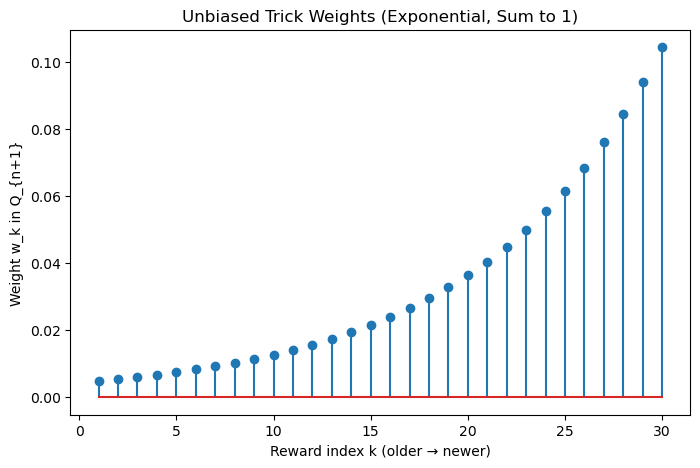

In [2]:

alpha = 0.1
n = 30
w = unbiased_weights(alpha, n)
print("Sum of weights =", w.sum())
plt.figure(figsize=(8,5))
plt.stem(np.arange(1, n+1), w, use_line_collection=True)
plt.xlabel("Reward index k (older → newer)")
plt.ylabel("Weight w_k in Q_{n+1}")
plt.title("Unbiased Trick Weights (Exponential, Sum to 1)")
plt.show()


### Initial bias comparison: constant α vs unbiased

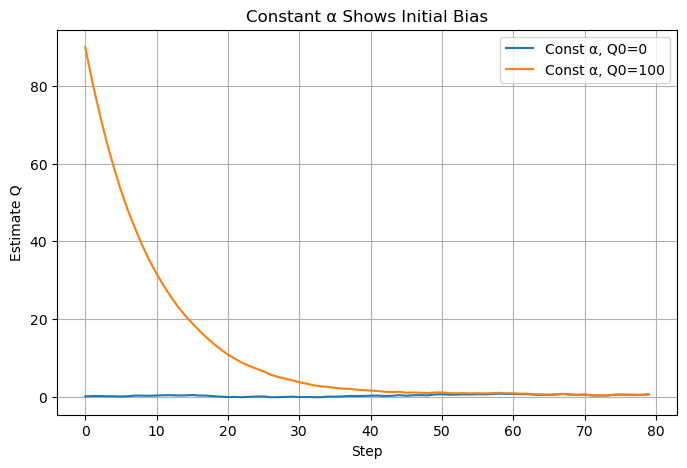

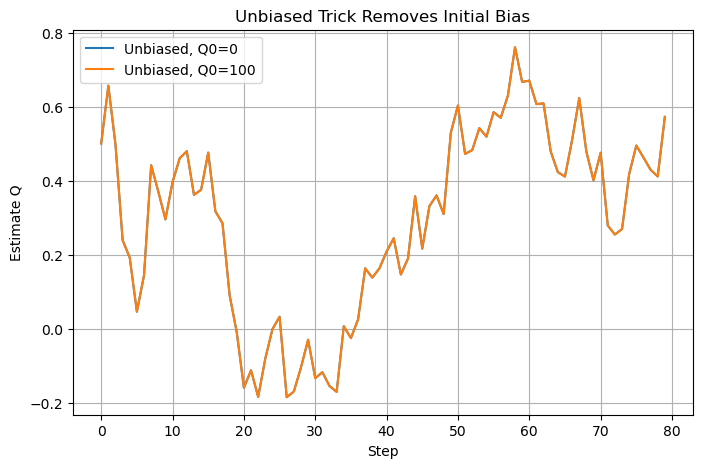

In [3]:

def compare_initial_bias(alpha=0.1, n=60, Q0_a=0.0, Q0_b=100.0, seed=1):
    rng = np.random.default_rng(seed)
    q = 0.5
    rewards = rng.normal(q, 1.0, size=n)

    def apply(method, Q0):
        Q = Q0
        o = 0.0
        traj = []
        for r in rewards:
            if method == 'const_alpha':
                Q = Q + alpha * (r - Q)
            elif method == 'unbiased':
                o = o + alpha * (1 - o)
                beta = alpha / o
                Q = Q + beta * (r - Q)
            traj.append(Q)
        return np.array(traj)

    const_a = apply('const_alpha', Q0_a)
    const_b = apply('const_alpha', Q0_b)
    unb_a = apply('unbiased', Q0_a)
    unb_b = apply('unbiased', Q0_b)

    return const_a, const_b, unb_a, unb_b

const_a, const_b, unb_a, unb_b = compare_initial_bias(alpha=0.1, n=80, Q0_a=0.0, Q0_b=100.0, seed=7)

plt.figure(figsize=(8,5))
plt.plot(const_a, label="Const α, Q0=0")
plt.plot(const_b, label="Const α, Q0=100")
plt.xlabel("Step"); plt.ylabel("Estimate Q"); plt.title("Constant α Shows Initial Bias")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(8,5))
plt.plot(unb_a, label="Unbiased, Q0=0")
plt.plot(unb_b, label="Unbiased, Q0=100")
plt.xlabel("Step"); plt.ylabel("Estimate Q"); plt.title("Unbiased Trick Removes Initial Bias")
plt.legend(); plt.grid(True); plt.show()


### Stationary vs Nonstationary comparison

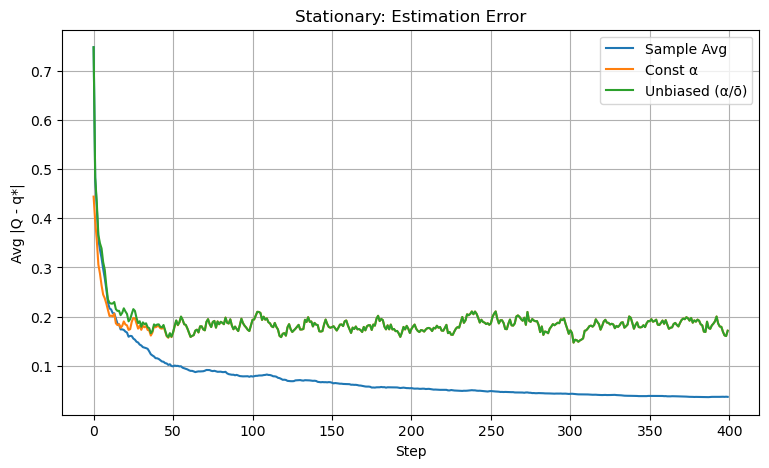

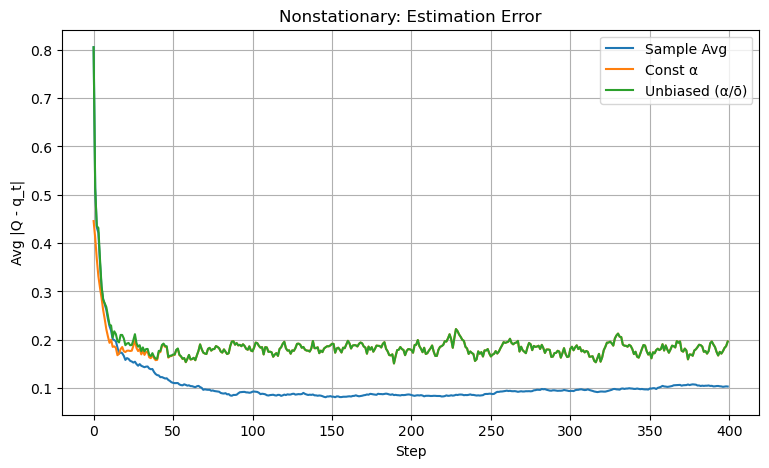

In [4]:

def simulate_bandit(method, n_steps=400, n_runs=150, alpha=0.1, nonstationary=False, seed=0):
    rng = np.random.default_rng(seed)
    avg_abs_error = np.zeros(n_steps)
    avg_estimate = np.zeros(n_steps)

    for run in range(n_runs):
        q = 0.5
        Q = 0.0
        o = 0.0
        for t in range(n_steps):
            if nonstationary and t > 0:
                q += rng.normal(0, 0.01)
            r = rng.normal(q, 1.0)

            if method == 'sample_avg':
                if t == 0:
                    Q = r
                else:
                    Q = Q + (r - Q) / (t + 1)
            elif method == 'const_alpha':
                Q = Q + alpha * (r - Q)
            elif method == 'unbiased':
                o = o + alpha * (1 - o)
                beta = alpha / o
                Q = Q + beta * (r - Q)

            avg_abs_error[t] += abs(Q - q)
            avg_estimate[t] += Q

    avg_abs_error /= n_runs
    avg_estimate /= n_runs
    return avg_abs_error, avg_estimate

methods = ['sample_avg', 'const_alpha', 'unbiased']
labels = {'sample_avg':'Sample Avg', 'const_alpha':'Const α', 'unbiased':'Unbiased (α/ō)'}

# Stationary
res_stat = {m: simulate_bandit(m, n_steps=400, n_runs=150, alpha=0.1, nonstationary=False, seed=123) for m in methods}
plt.figure(figsize=(9,5))
for m in methods:
    plt.plot(res_stat[m][0], label=labels[m])
plt.xlabel("Step"); plt.ylabel("Avg |Q - q*|"); plt.title("Stationary: Estimation Error")
plt.grid(True); plt.legend(); plt.show()

# Nonstationary
res_nonstat = {m: simulate_bandit(m, n_steps=400, n_runs=150, alpha=0.1, nonstationary=True, seed=123) for m in methods}
plt.figure(figsize=(9,5))
for m in methods:
    plt.plot(res_nonstat[m][0], label=labels[m])
plt.xlabel("Step"); plt.ylabel("Avg |Q - q_t|"); plt.title("Nonstationary: Estimation Error")
plt.grid(True); plt.legend(); plt.show()
